# Autoencoder from Scratch

An autoencoder is a network trained to copy its input to its output through a layer too small to
hold it. The first half, the encoder, maps the input to a short code; the second half, the decoder,
maps the code back to the input space. Nothing but the input is used as the target, so no labels are
involved at any point in training.

$$\mathbf{z} = f(W_e\mathbf{x} + \mathbf{b}_e), \qquad
\hat{\mathbf{x}} = g(W_d\mathbf{z} + \mathbf{b}_d)$$

with $\dim(\mathbf{z}) \ll \dim(\mathbf{x})$. The bottleneck is the whole point. Given a code as wide
as the input the network would learn the identity map and store nothing; forced through $k$ numbers
it has to decide which $k$ numbers about a digit are worth keeping.

The data is the UCI handwritten digits used by `2d_cnn_from_scratch.ipynb` and
`mlp_from_scratch.ipynb`, 5,620 images of 8x8 pixels. Because the input is an image, a code and its
reconstruction can be drawn and compared by eye, and the features the decoder learns can be put next
to the ones those two supervised networks learned from the same pixels.

Three variants are built from one class:

- a **linear** autoencoder, with no activations, which is shown to reach the same reconstruction
  error as PCA at every bottleneck size and to span the same subspace,
- a **non-linear** autoencoder, ReLU in the hidden layers, which is not confined to a linear
  subspace and beats PCA at small $k$,
- a **denoising** autoencoder, trained to reconstruct a clean digit from a corrupted one.

Forward and backward passes are written out by hand and checked against finite differences before
any training happens. The digit labels appear only to colour a scatter plot and to score the codes
in the last section.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green = '#2a78d6', '#eb6834', '#1baf7a'

notebook_start = time.time()

## Loading the data

`fetch_ucirepo(id=80)` downloads 5,620 handwritten digits. Each row is 64 numbers holding an 8x8
image flattened out, with pixel values from 0 to 16, so dividing by 16 puts every feature in
$[0, 1]$ and a squared error over the 64 pixels is a sum of comparable terms.

The shuffle uses seed 0 and the split is 80/20, matching the two supervised notebooks on this data.
The training labels `y_train` are loaded but not passed to any model until the final section.

In [2]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float) / 16.0
y_all = digits.data.targets.values.ravel()

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

train_idx, test_idx = order[:split], order[split:]
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print('features:', X_all.shape, ' pixel range:', X_all.min(), 'to', X_all.max())
print('train:', X_train.shape, ' test:', X_test.shape)
print('class counts:', np.bincount(y_all))

features: (5620, 64)  pixel range: 0.0 to 1.0
train: (4496, 64)  test: (1124, 64)
class counts: [554 571 557 572 568 558 558 566 554 562]


The cell below draws ten training digits. These same ten are used further down to show
reconstructions, so the effect of the bottleneck can be read off the same images.

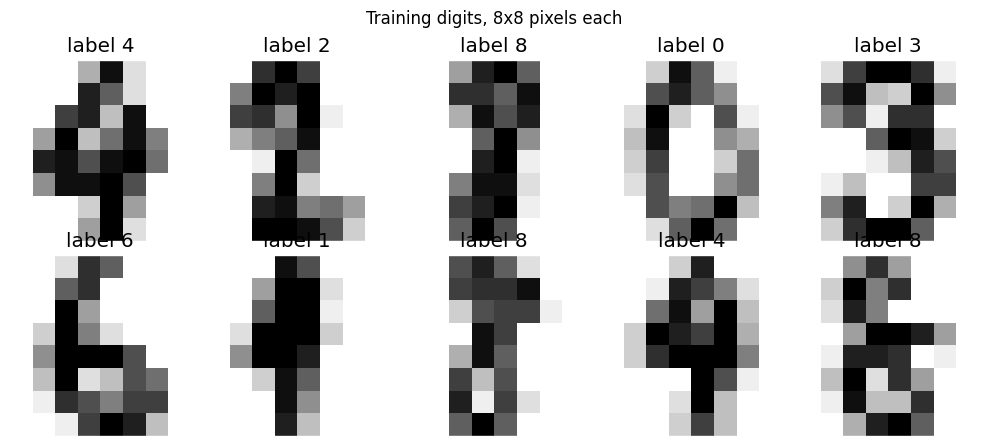

In [3]:
show = np.arange(10)

fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, i in zip(ax.ravel(), show):
    a.imshow(X_train[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    a.set_title(f'label {y_train[i]}')
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

plt.suptitle('Training digits, 8x8 pixels each')
plt.tight_layout()
plt.show()

## The objective

There is no label, so the target is the input itself. Over $N$ samples the loss is the mean squared
distance between an image and its reconstruction:

$$J = \frac{1}{N}\sum_{i=1}^{N}\lVert \mathbf{x}_i - \hat{\mathbf{x}}_i \rVert^2$$

The norm runs over all 64 pixels, so $J$ is a per-image number and a value of 1.0 means the
reconstruction is off by a total squared amount of 1 across the whole image. That is hard to picture,
so every result below is also quoted as a per-pixel root mean squared error

$$\mathrm{RMSE} = \sqrt{J / 64}$$

which is in the same units as the pixels themselves, $[0, 1]$. An RMSE of 0.10 means the average
pixel is a tenth of the full ink range away from where it should be.

The two functions below compute both. `recon_loss` sums over pixels then averages over images;
`per_pixel_rmse` averages over everything and takes the root.

In [4]:
def recon_loss(X, R):
    # mean over images of the squared distance summed over the 64 pixels
    return np.mean(np.sum((X - R) ** 2, axis=1))


def per_pixel_rmse(X, R):
    return np.sqrt(np.mean((X - R) ** 2))


print('loss of predicting the training mean for every image:')
mean_image = X_train.mean(axis=0)
flat = np.tile(mean_image, (len(X_train), 1))
print(f'  J = {recon_loss(X_train, flat):.4f}   per-pixel RMSE = {per_pixel_rmse(X_train, flat):.4f}')

loss of predicting the training mean for every image:
  J = 4.6992   per-pixel RMSE = 0.2710


## The forward pass

The network is an ordinary feed-forward stack. Writing $\mathbf{a}^{(0)} = \mathbf{x}$, layer $l$
computes

$$\mathbf{z}^{(l)} = W^{(l)\top}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}, \qquad
\mathbf{a}^{(l)} = g(\mathbf{z}^{(l)})$$

with $W^{(l)}$ stored as (units in $l-1$) x (units in $l$) and one sample per row, so the code line
is `z = a @ W + b`. The encoder is the first half of the stack and the decoder is the second half;
they are only different names for the layers before and after the narrowest one.

The hidden activation is the rectifier $g(z) = \max(0, z)$ with $g'(z) = \mathbb{1}[z > 0]$. Two
layers keep no activation:

- **the output layer**, because a pixel value is a real number to be matched, not a probability, and
  the squared loss is happy with any real output,
- **the bottleneck layer**, so the code is unrestricted in sign. A ReLU there would force every
  coordinate of $\mathbf{z}$ to be non-negative, which throws away half of the code space for no
  reason.

Setting `activation=False` removes every ReLU and leaves a stack of affine maps. As shown in
`mlp_from_scratch.ipynb`, such a stack collapses to a single affine map, so the network then computes
$\hat{\mathbf{x}} = W_dW_e\mathbf{x} + \mathbf{b}'$ - that is the linear autoencoder, and the whole
first result of this notebook is about what its optimum turns out to be.

## The backward pass

Define the error signal at layer $l$ as the derivative of the loss with respect to that layer's
pre-activation, $\boldsymbol\delta^{(l)} = \partial J / \partial \mathbf{z}^{(l)}$.

**Output layer.** The last layer is linear, so $\hat{\mathbf{x}} = \mathbf{z}^{(L)}$ and

$$\frac{\partial}{\partial \hat{x}_j}\frac{1}{N}\sum_i \lVert \mathbf{x}_i - \hat{\mathbf{x}}_i\rVert^2
= \frac{2}{N}\left(\hat{x}_j - x_j\right)
\quad\Longrightarrow\quad
\boldsymbol\delta^{(L)} = \frac{2}{N}\left(\hat{\mathbf{x}} - \mathbf{x}\right)$$

This is the only place the objective enters. Everything after it is the same recurrence any
feed-forward network uses.

**Every other layer.** $\mathbf{z}^{(l)}$ reaches the loss only through $\mathbf{z}^{(l+1)}$, and
$z^{(l+1)}_j = \sum_i W^{(l+1)}_{ij} g(z^{(l)}_i) + b^{(l+1)}_j$, so the chain rule gives

$$\boldsymbol\delta^{(l)} = \left(W^{(l+1)}\boldsymbol\delta^{(l+1)}\right) \odot g'(\mathbf{z}^{(l)})$$

with $\odot$ the elementwise product. The parameter gradients then read off directly from
$\mathbf{z}^{(l)} = W^{(l)\top}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$:

$$\frac{\partial J}{\partial W^{(l)}} = \mathbf{a}^{(l-1)}\boldsymbol\delta^{(l)\top}, \qquad
\frac{\partial J}{\partial \mathbf{b}^{(l)}} = \boldsymbol\delta^{(l)}$$

summed over the batch. Because the encoder and decoder are one stack, the gradient that trains the
encoder is the decoder's error signal pushed back through the bottleneck - the encoder is told what
to keep only by how much the decoder's output suffers when it does not.

## Initialisation and the update rule

Weights start from He initialisation, $\sigma = \sqrt{2 / n_{\text{in}}}$, which keeps the variance
of the signal roughly constant across layers, and biases start at zero. Zero weights would leave
every unit in a layer identical forever, since they would all receive the same gradient.

The parameters are moved by Adam rather than plain SGD. Adam keeps a running mean $m$ and a running
mean of squares $v$ of each parameter's gradient,

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2, \qquad
\theta_t = \theta_{t-1} - \alpha \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}$$

with $\hat m_t = m_t / (1 - \beta_1^t)$ and $\hat v_t = v_t / (1 - \beta_2^t)$ correcting the bias
that comes from starting both averages at zero. Dividing by $\sqrt{\hat v_t}$ makes the step size per
parameter roughly independent of the gradient's scale. That matters here more than it did for
classification: the reconstruction gradients for a rarely-lit corner pixel and for a central pixel
differ by orders of magnitude, and a single global learning rate suits one or the other but not both.
The measurement that follows compares an autoencoder's optimum against the exact PCA optimum, so how
close the optimiser gets is part of the result.

## The class

`Autoencoder` takes a symmetric list of layer sizes, `[64, 32, k, 32, 64]` for instance, and builds
one weight matrix and one bias per consecutive pair. `forward` stores each layer's input and
pre-activation for the backward pass, skipping the ReLU at the output and at the bottleneck.
`backward` runs the recurrence above from the last layer to the first. `encode` and `decode` run the
two halves separately, which is what the code scatter, the interpolation and the decoder-only
generation need. `fit` does mini-batch training with a step-size decay late in the run, and accepts
a `noise` level which corrupts the input while leaving the target clean - the denoising variant is
that one argument.

In [5]:
class Autoencoder:
    def __init__(self, layer_sizes, learning_rate=0.006, activation=True, seed=0):
        r = np.random.default_rng(seed)

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.activation = activation
        self.middle = len(layer_sizes) // 2
        self.weights = []
        self.biases = []
        self.history = {'train_loss': [], 'test_loss': []}

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            # He initialisation: sqrt(2 / fan_in)
            self.weights.append(r.normal(0, np.sqrt(2 / fan_in), (fan_in, fan_out)))
            self.biases.append(np.zeros(fan_out))

        # Adam moment estimates, one pair per parameter array
        self.mw = [np.zeros_like(w) for w in self.weights]
        self.vw = [np.zeros_like(w) for w in self.weights]
        self.mb = [np.zeros_like(b) for b in self.biases]
        self.vb = [np.zeros_like(b) for b in self.biases]
        self.step = 0

    def _act(self, z, i):
        # no ReLU at the output layer or at the bottleneck
        if not self.activation or i == len(self.weights) - 1 or i == self.middle - 1:
            return z
        return np.maximum(0, z)

    def forward(self, X):
        self.activations = [X]
        self.zs = []
        a = X

        for i in range(len(self.weights)):
            z = a @ self.weights[i] + self.biases[i]
            a = self._act(z, i)
            self.zs.append(z)
            self.activations.append(a)

        return a

    def backward(self, output, target):
        n = len(target)
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        # squared error through a linear output layer
        delta = 2.0 * (output - target) / n

        for i in range(len(self.weights) - 1, -1, -1):
            grads_w[i] = self.activations[i].T @ delta
            grads_b[i] = delta.sum(axis=0)

            if i > 0:
                delta = delta @ self.weights[i].T
                # ReLU derivative, unless that layer had no activation
                if self.activation and (i - 1) != self.middle - 1:
                    delta = delta * (self.zs[i - 1] > 0)

        return grads_w, grads_b

    def update(self, grads_w, grads_b, lr):
        self.step += 1
        b1, b2, eps = 0.9, 0.999, 1e-8
        c1 = 1 - b1 ** self.step
        c2 = 1 - b2 ** self.step

        for i in range(len(self.weights)):
            self.mw[i] = b1 * self.mw[i] + (1 - b1) * grads_w[i]
            self.vw[i] = b2 * self.vw[i] + (1 - b2) * grads_w[i] ** 2
            self.weights[i] -= lr * (self.mw[i] / c1) / (np.sqrt(self.vw[i] / c2) + eps)

            self.mb[i] = b1 * self.mb[i] + (1 - b1) * grads_b[i]
            self.vb[i] = b2 * self.vb[i] + (1 - b2) * grads_b[i] ** 2
            self.biases[i] -= lr * (self.mb[i] / c1) / (np.sqrt(self.vb[i] / c2) + eps)

    def fit(self, X, X_val=None, epochs=150, batch_size=128, noise=0.0, seed=0, report_every=0):
        r = np.random.default_rng(seed)

        for e in range(epochs):
            # hold the step size, then shrink it twice near the end
            lr = self.learning_rate * (0.2 if e > 0.85 * epochs else 0.5 if e > 0.6 * epochs else 1.0)
            idx = r.permutation(len(X))

            for s in range(0, len(X), batch_size):
                target = X[idx[s:s + batch_size]]
                # the denoising variant corrupts the input only
                inputs = target if noise == 0 else np.clip(target + r.normal(0, noise, target.shape), 0, 1)
                grads_w, grads_b = self.backward(self.forward(inputs), target)
                self.update(grads_w, grads_b, lr)

            self.history['train_loss'].append(recon_loss(X, self.forward(X)))
            if X_val is not None:
                self.history['test_loss'].append(recon_loss(X_val, self.forward(X_val)))

            if report_every and (e + 1) % report_every == 0:
                print(f'  epoch {e + 1:4d}  train J {self.history["train_loss"][-1]:.5f}')

    def encode(self, X):
        a = X
        for i in range(self.middle):
            a = self._act(a @ self.weights[i] + self.biases[i], i)
        return a

    def decode(self, Z):
        a = Z
        for i in range(self.middle, len(self.weights)):
            a = self._act(a @ self.weights[i] + self.biases[i], i)
        return a

    def parameter_count(self):
        return sum(w.size for w in self.weights) + sum(b.size for b in self.biases)

## Checking the derivatives

A wrong backward pass throws no error; the network simply trains worse than it should, which looks
like a badly chosen step size. The definition of the derivative gives a way to measure the truth:
nudge one weight by $\varepsilon$ each way and take the central difference

$$\frac{\partial J}{\partial w} \approx \frac{J(w + \varepsilon) - J(w - \varepsilon)}{2\varepsilon}$$

which is accurate to $O(\varepsilon^2)$, unlike the one-sided version. With $\varepsilon = 10^{-5}$
in double precision the analytic and measured values should agree to about eight decimals; closer is
prevented by cancellation in the numerator, further apart means the derivation is wrong.

The cell builds a small network with the same shape as the real one, runs one batch through it, and
compares. The entries checked are the ones with the largest gradient magnitude in each layer, since
agreement at a coordinate whose gradient is near zero proves nothing.

In [6]:
check_net = Autoencoder([64, 20, 5, 20, 64], seed=3)
Xb = X_train[:16]

out = check_net.forward(Xb)
grads_w, grads_b = check_net.backward(out, Xb)

eps = 1e-5


def measured_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = recon_loss(Xb, check_net.forward(Xb))
    param[index] = original - eps
    down = recon_loss(Xb, check_net.forward(Xb))
    param[index] = original
    return (up - down) / (2 * eps)


print(f'{"parameter":22s} {"from backward":>16s} {"measured":>16s} {"difference":>13s}')

for layer in range(len(check_net.weights)):
    g = grads_w[layer]
    # the three weights in this layer with the largest gradient
    for f in np.argsort(np.abs(g).ravel())[::-1][:3]:
        index = np.unravel_index(f, g.shape)
        slope = measured_slope(check_net.weights[layer], index)
        print(f'W{layer} {str(index):18s} {g[index]:16.8f} {slope:16.8f} {abs(g[index] - slope):13.2e}')

for layer in range(len(check_net.biases)):
    g = grads_b[layer]
    index = (int(np.argmax(np.abs(g))),)
    slope = measured_slope(check_net.biases[layer], index)
    print(f'b{layer} {str(index):18s} {g[index]:16.8f} {slope:16.8f} {abs(g[index] - slope):13.2e}')

parameter                 from backward         measured    difference
W0 (60, 1)                 20.99273295      20.99273295      6.35e-10
W0 (26, 1)                 20.73436594      20.73436594      1.52e-10
W0 (4, 1)                  19.52269631      19.52269631      2.25e-10
W1 (17, 0)                -64.74416794     -64.74416794      2.25e-10
W1 (17, 4)                 52.62497954      52.62497954      4.14e-11
W1 (18, 0)                -41.61237859     -41.61237859      1.01e-10
W2 (0, 17)                -24.89206933     -24.89206933      3.49e-10
W2 (4, 17)                 24.60370784      24.60370784      2.10e-10
W2 (4, 7)                   6.84281415       6.84281415      3.51e-10
W3 (17, 58)                -7.77626207      -7.77626207      1.35e-10
W3 (17, 19)                -7.61687147      -7.61687147      1.80e-10
W3 (17, 13)                -6.44663845      -6.44663845      5.51e-11
b0 (1,)                    26.56892465      26.56892465      2.17e-10
b1 (0,)            

Every pair agrees to eight decimals. What remains is the truncation error of the finite difference,
not a mistake in the recurrence, and both the ReLU layers and the two linear ones are covered.

## PCA, written out

The linear autoencoder is going to be compared against principal component analysis, so PCA is
computed here directly rather than assumed. Centre the data and take the singular value
decomposition of the $N \times 64$ matrix,

$$X - \mathbf{1}\bar{\mathbf{x}}^\top = U\Sigma V^\top$$

The principal components are the leading columns of $V$, an orthonormal basis for the $k$-dimensional
subspace that captures the most variance. Projecting onto it and back gives the rank-$k$
reconstruction

$$\hat{\mathbf{x}} = \bar{\mathbf{x}} + V_kV_k^\top(\mathbf{x} - \bar{\mathbf{x}})$$

and, on the data PCA was fitted to, the resulting error is exactly the discarded spectrum:

$$\sum_i \lVert \mathbf{x}_i - \hat{\mathbf{x}}_i \rVert^2 = \sum_{j > k} \sigma_j^2$$

The cell computes the decomposition, checks that identity against the reconstruction error measured
directly, and prints the error for each bottleneck size that will be used.

In [7]:
pca_mean = X_train.mean(axis=0)
U, S, Vt = np.linalg.svd(X_train - pca_mean, full_matrices=False)
components = Vt.T


def pca_reconstruct(X, k):
    Vk = components[:, :k]
    return pca_mean + (X - pca_mean) @ Vk @ Vk.T


ks = [2, 4, 8, 16, 32]

print(f'{"k":>4s} {"J train":>10s} {"sum sigma^2 / N":>17s} {"J test":>10s} {"RMSE test":>11s}')
for k in ks:
    tail = (S[k:] ** 2).sum() / len(X_train)
    tr = recon_loss(X_train, pca_reconstruct(X_train, k))
    te = recon_loss(X_test, pca_reconstruct(X_test, k))
    print(f'{k:4d} {tr:10.5f} {tail:17.5f} {te:10.5f} {per_pixel_rmse(X_test, pca_reconstruct(X_test, k)):11.5f}')

print()
print('largest gap between measured error and the discarded eigenvalue sum:',
      f'{max(abs(recon_loss(X_train, pca_reconstruct(X_train, k)) - (S[k:] ** 2).sum() / len(X_train)) for k in ks):.2e}')

   k    J train   sum sigma^2 / N     J test   RMSE test
   2    3.38324           3.38324    3.39121     0.23019
   4    2.43566           2.43566    2.43096     0.19489
   8    1.54416           1.54416    1.56034     0.15614
  16    0.71291           0.71291    0.72799     0.10665
  32    0.16385           0.16385    0.17325     0.05203



largest gap between measured error and the discarded eigenvalue sum: 4.44e-16


## The linear autoencoder and PCA

With no activations and squared-error loss, the network computes $\hat{\mathbf{x}} = W_dW_e\mathbf{x}
+ \mathbf{b}'$, where $W_e$ is $64 \times k$ and $W_d$ is $k \times 64$. Whatever the pair does, the
product has rank at most $k$, so the reconstruction always lies in a $k$-dimensional affine subspace.
Minimising squared error over all such subspaces is exactly the problem PCA solves, so **the optimal
linear autoencoder with bottleneck $k$ attains the same reconstruction error as PCA with $k$
components, and its decoder spans the same subspace as the first $k$ principal components.**

The statement is about the subspace and not about the axes. If $A$ is any invertible $k \times k$
matrix then

$$W_dW_e = (W_dA^{-1})(AW_e)$$

so replacing $W_e$ by $AW_e$ and $W_d$ by $W_dA^{-1}$ changes the code completely and leaves the
output and the loss untouched. The individual coordinates of $\mathbf{z}$ are therefore not
identified: they are fixed only up to an arbitrary rotation, scaling and shearing. Nothing pushes
them to be orthogonal, ordered by variance, or equal to the principal components, and comparing $W_d$
against $V_k$ entry by entry would report a disagreement that is not there. What is identified is the
span, and that is what gets compared.

The cell trains a linear autoencoder at each bottleneck size and prints its error next to PCA's.

## The plane settling onto the principal subspace

The animation below trains the linear autoencoder and draws where its decoder points. The digits
are plotted in the frame of the first three principal components, so the PCA target is the flat
horizontal plane; the decoder's own plane swings down and settles onto it while the loss falls
onto the dashed PCA optimum and the principal angles collapse from about 86 degrees to a few.

Everything measured is measured in the full 64-dimensional pixel space - only the drawing is
three-dimensional.

The distinction that matters: the autoencoder does **not** learn the principal components. It
learns the same *subspace*, and within that subspace its axes can be rotated and rescaled
arbitrarily, because for any invertible $A$

$$W_d W_e = (W_d A^{-1})(A W_e)$$

gives an identical reconstruction. Nothing in the objective prefers one choice of $A$ over
another, so comparing weight matrices against PCA's components would be comparing two arbitrary
coordinate choices. Comparing principal angles between the subspaces asks the question that
actually has an answer, which is why that is what the cells below compute.

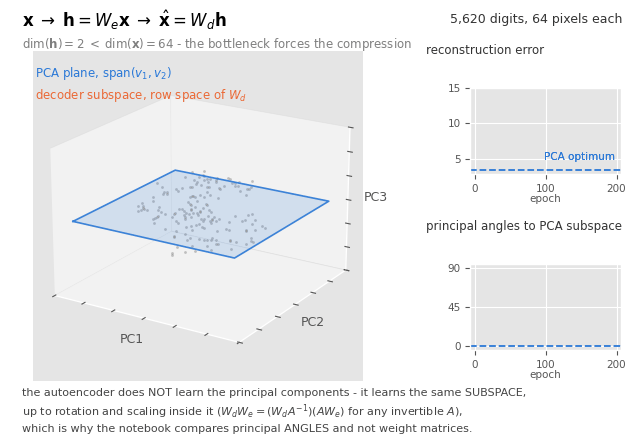

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/autoencoder_pca.gif')

In [8]:
linear_models = {}
start = time.time()

print(f'{"k":>4s} {"PCA J":>10s} {"linear AE J":>12s} {"ratio":>8s} {"PCA RMSE":>10s} {"AE RMSE":>9s}')
for k in ks:
    ae = Autoencoder([64, k, 64], learning_rate=0.006, activation=False, seed=0)
    ae.fit(X_train, X_test, epochs=200, batch_size=128, seed=0)
    linear_models[k] = ae

    pj = recon_loss(X_train, pca_reconstruct(X_train, k))
    aj = ae.history['train_loss'][-1]
    print(f'{k:4d} {pj:10.5f} {aj:12.5f} {aj / pj:8.5f}'
          f' {per_pixel_rmse(X_train, pca_reconstruct(X_train, k)):10.5f}'
          f' {per_pixel_rmse(X_train, ae.forward(X_train)):9.5f}')

print()
print(f'training time: {time.time() - start:.1f} s')

   k      PCA J  linear AE J    ratio   PCA RMSE   AE RMSE


   2    3.38324      3.38384  1.00018    0.22992   0.22994


   4    2.43566      2.43583  1.00007    0.19508   0.19509


   8    1.54416      1.54499  1.00054    0.15533   0.15537


  16    0.71291      0.71344  1.00075    0.10554   0.10558


  32    0.16385      0.16476  1.00555    0.05060   0.05074

training time: 10.7 s


The two columns agree to a few parts in a thousand. The autoencoder is never below PCA, which is the
right way round - PCA is the exact minimiser over rank-$k$ maps, so nothing can beat it, and the
small excess is what gradient descent has left on the table after a finite number of steps rather
than a difference in what the two models can represent.

## Comparing the subspaces

Reaching the same loss is suggestive but not conclusive, so the subspaces are compared directly.
Take an orthonormal basis $Q_1$ of the decoder's row space, obtained from a QR factorisation of
$W_d^\top$, and an orthonormal basis $Q_2 = V_k$ of the PCA subspace. The singular values
$\cos\theta_1 \ge \dots \ge \cos\theta_k$ of $Q_1^\top Q_2$ are the cosines of the principal angles
between the two subspaces. All angles zero means the subspaces are identical; an angle of 90 degrees
means a direction in one is orthogonal to the whole of the other.

A second, blunter check is also printed: the fraction of the decoder basis that survives projection
onto the PCA subspace,

$$\frac{\lVert V_kV_k^\top Q_1\rVert_F^2}{\lVert Q_1 \rVert_F^2} \in [0, 1]$$

which is 1 when the decoder lies entirely inside the PCA subspace. A random $k$-dimensional subspace
of $\mathbb{R}^{64}$ is included as a control, since with $k = 32$ a large overlap could be had by
accident.

In [9]:
def principal_angles(A, B):
    # columns of A and B span the two subspaces
    Q1, _ = np.linalg.qr(A)
    Q2, _ = np.linalg.qr(B)
    cosines = np.linalg.svd(Q1.T @ Q2, compute_uv=False)
    return np.degrees(np.arccos(np.clip(cosines, -1, 1))), Q1


def overlap(Q1, Vk):
    projected = Vk @ (Vk.T @ Q1)
    return (projected ** 2).sum() / (Q1 ** 2).sum()


r = np.random.default_rng(1)

print(f'{"k":>4s} {"largest angle":>14s} {"mean angle":>11s} {"overlap":>9s} {"random overlap":>15s}')
for k in ks:
    Vk = components[:, :k]
    angles, Q1 = principal_angles(linear_models[k].weights[1].T, Vk)
    _, Qr = principal_angles(r.normal(size=(64, k)), Vk)
    print(f'{k:4d} {angles.max():13.4f}d {angles.mean():10.4f}d'
          f' {overlap(Q1, Vk):9.5f} {overlap(Qr, Vk):15.5f}')

   k  largest angle  mean angle   overlap  random overlap
   2        4.1897d     2.2487d   0.99732         0.01419
   4        0.5031d     0.3150d   0.99997         0.08892
   8       14.2481d     2.0635d   0.99240         0.13462
  16        6.6469d     0.7134d   0.99913         0.25530
  32       24.0293d     1.1334d   0.99467         0.50659


The principal angles are a fraction of a degree and the overlap is 1 to several decimals, while the
random control sits near $k/64$, the value expected when nothing is shared. The trained decoder and
the leading principal components describe the same subspace of pixel space.

The weight matrices themselves are a different story, and the cell below shows it: the decoder rows
are neither orthogonal nor aligned with the components. The subspace is learned; the coordinate
system on it is arbitrary.

In [10]:
k = 8
Wd = linear_models[k].weights[1]
Vk = components[:, :k]

gram = Wd @ Wd.T
off_diagonal = np.abs(gram - np.diag(np.diag(gram))).max()

print('decoder shape                       :', Wd.shape)
print('largest off-diagonal of Wd Wd^T     :', f'{off_diagonal:.5f}   (0 would mean orthogonal rows)')
print('row norms of Wd                     :', np.round(np.linalg.norm(Wd, axis=1), 3))
print('largest |Wd_ij - V_ji|              :', f'{np.abs(Wd - Vk.T).max():.5f}')
print()
print('but the reconstructions match:')
print('  max |AE output - PCA output| on test:',
      f'{np.abs(linear_models[k].forward(X_test) - pca_reconstruct(X_test, k)).max():.5f}')
print('  mean |AE output - PCA output|       :',
      f'{np.abs(linear_models[k].forward(X_test) - pca_reconstruct(X_test, k)).mean():.5f}')

decoder shape                       : (8, 64)
largest off-diagonal of Wd Wd^T     : 4.74845   (0 would mean orthogonal rows)
row norms of Wd                     : [3.513 2.907 3.352 3.005 3.049 2.565 2.668 3.942]
largest |Wd_ij - V_ji|              : 2.41713

but the reconstructions match:
  max |AE output - PCA output| on test: 0.14444
  mean |AE output - PCA output|       : 0.01052


## The non-linear autoencoder

The linear model can only ever project onto a flat subspace. Digits do not lie on a flat subspace:
the set of images produced by writing a 3 in different hands is a curved, low-dimensional sheet in
the 64-dimensional pixel cube, and a plane can only be fitted through it. Putting ReLU layers on both
sides of the bottleneck lets the encoder bend the input space before compressing it and lets the
decoder bend it back, so the $k$ numbers can parameterise a curved surface rather than a plane.

The architecture is $64 \to h \to k \to h \to 64$ with ReLU in the two hidden layers, and $h$ wider
than $k$ so the bending happens somewhere. It has far more parameters than the linear model, which is
not the reason it can do better - a wider linear model would still be a projection. The reason is the
shape of the family, not its size.

The cell trains one at each bottleneck size and prints the improvement over PCA.

In [11]:
nonlinear_models = {}
start = time.time()

print(f'{"k":>4s} {"PCA J":>10s} {"non-linear J":>13s} {"change":>9s} {"PCA RMSE":>10s} {"AE RMSE":>9s} {"params":>8s}')
for k in ks:
    ae = Autoencoder([64, 128, k, 128, 64], learning_rate=0.004, seed=0)
    ae.fit(X_train, X_test, epochs=150, batch_size=128, seed=0)
    nonlinear_models[k] = ae

    pj = recon_loss(X_train, pca_reconstruct(X_train, k))
    aj = ae.history['train_loss'][-1]
    print(f'{k:4d} {pj:10.5f} {aj:13.5f} {100 * (aj - pj) / pj:8.1f}%'
          f' {per_pixel_rmse(X_train, pca_reconstruct(X_train, k)):10.5f}'
          f' {per_pixel_rmse(X_train, ae.forward(X_train)):9.5f} {ae.parameter_count():8d}')

print()
print(f'training time: {time.time() - start:.1f} s')

   k      PCA J  non-linear J    change   PCA RMSE   AE RMSE   params


   2    3.38324       1.77825    -47.4%    0.22992   0.16669    17218


   4    2.43566       1.15462    -52.6%    0.19508   0.13432    17732


   8    1.54416       0.64553    -58.2%    0.15533   0.10043    18760


  16    0.71291       0.38073    -46.6%    0.10554   0.07713    20816


  32    0.16385       0.12074    -26.3%    0.05060   0.04343    24928

training time: 46.9 s


The same comparison on the held-out digits, which PCA and the autoencoders were both fitted without.
A model that beat PCA on the training set by memorising it would give the difference back here.

In [12]:
print(f'{"k":>4s} {"PCA test J":>11s} {"linear AE":>11s} {"non-linear":>11s} {"NL vs PCA":>11s}')
for k in ks:
    pj = recon_loss(X_test, pca_reconstruct(X_test, k))
    lj = recon_loss(X_test, linear_models[k].forward(X_test))
    nj = recon_loss(X_test, nonlinear_models[k].forward(X_test))
    print(f'{k:4d} {pj:11.5f} {lj:11.5f} {nj:11.5f} {100 * (nj - pj) / pj:10.1f}%')

   k  PCA test J   linear AE  non-linear   NL vs PCA
   2     3.39121     3.39185     1.96151      -42.2%
   4     2.43096     2.43124     1.26624      -47.9%
   8     1.56034     1.55553     0.72654      -53.4%
  16     0.72799     0.72906     0.41493      -43.0%
  32     0.17325     0.17455     0.13141      -24.1%


## Reconstruction error against bottleneck size

The headline figure. Reconstruction error on the test digits against $k$, with all three curves on
the same axes, in total squared error on the left and per-pixel RMSE on the right. The linear
autoencoder should sit on top of the PCA curve, since it is solving the same problem; the non-linear
one below it wherever the extra flexibility is worth anything.

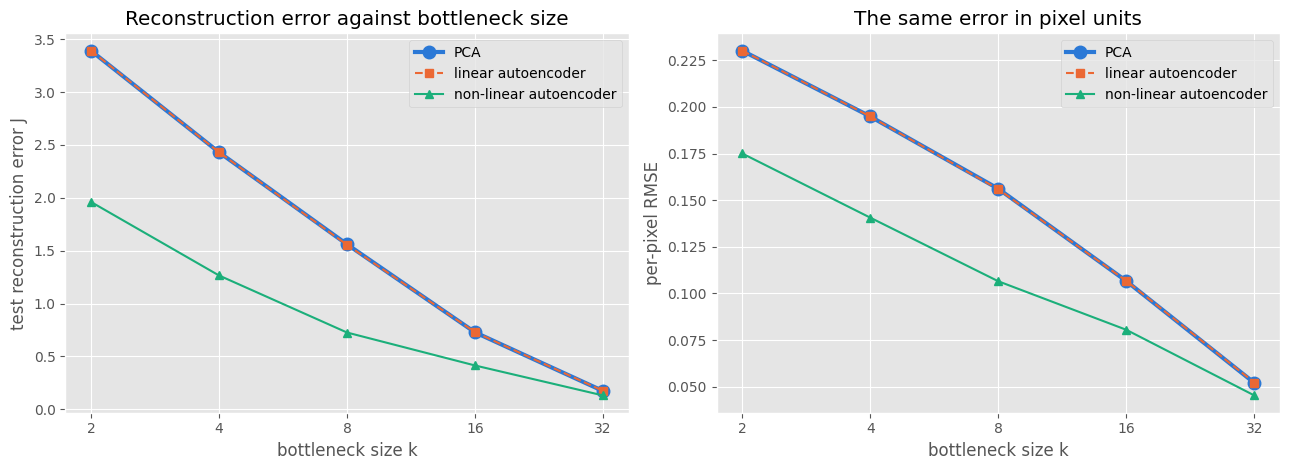

In [13]:
pca_curve = [recon_loss(X_test, pca_reconstruct(X_test, k)) for k in ks]
lin_curve = [recon_loss(X_test, linear_models[k].forward(X_test)) for k in ks]
nl_curve = [recon_loss(X_test, nonlinear_models[k].forward(X_test)) for k in ks]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

for a, scale in zip(ax, ['total', 'rmse']):
    f = (lambda v: v) if scale == 'total' else (lambda v: np.sqrt(np.array(v) / 64))
    a.plot(ks, f(pca_curve), 'o-', color=blue, label='PCA', linewidth=3, markersize=9)
    a.plot(ks, f(lin_curve), 's--', color=orange, label='linear autoencoder')
    a.plot(ks, f(nl_curve), '^-', color=green, label='non-linear autoencoder')
    a.set_xlabel('bottleneck size k')
    a.set_xscale('log', base=2)
    a.set_xticks(ks)
    a.set_xticklabels([str(k) for k in ks])
    a.legend()

ax[0].set_ylabel('test reconstruction error J')
ax[0].set_title('Reconstruction error against bottleneck size')
ax[1].set_ylabel('per-pixel RMSE')
ax[1].set_title('The same error in pixel units')

plt.tight_layout()
plt.show()

## What the reconstructions look like

Numbers for reconstruction error are hard to picture, so the same ten digits are put through the
non-linear autoencoder at each bottleneck size. The top row is the originals; each row below is the
output of a model that saw the digit only through $k$ numbers.

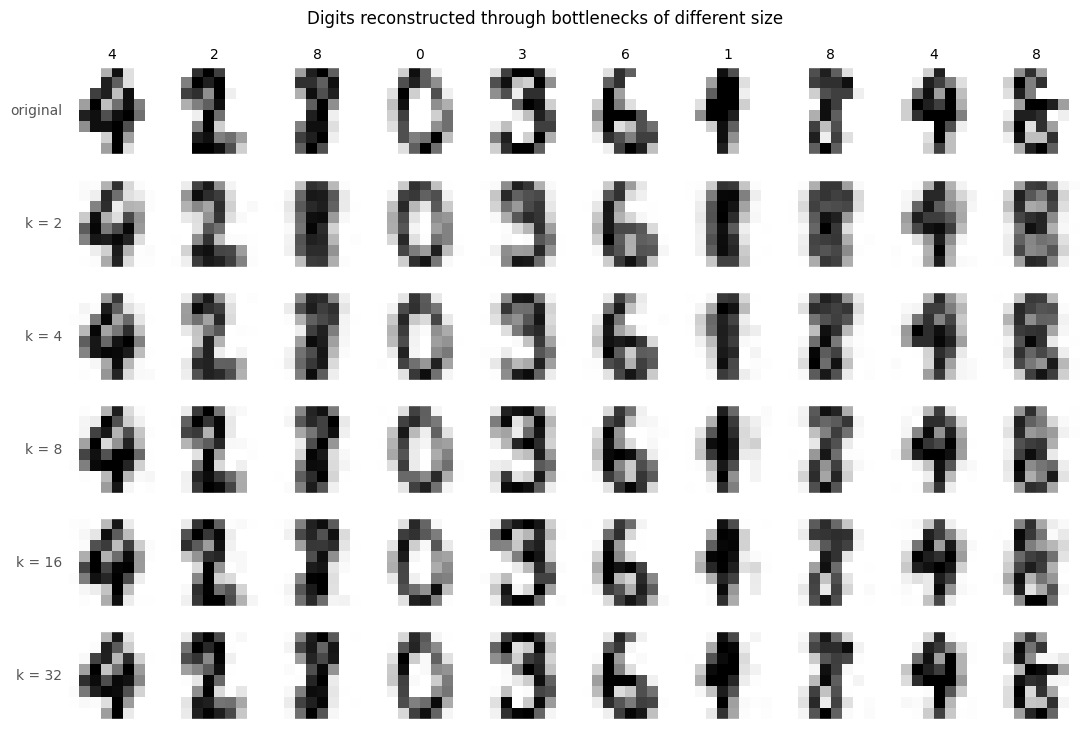

In [14]:
rows = [('original', X_train[show])] + [
    (f'k = {k}', nonlinear_models[k].forward(X_train[show])) for k in ks]

fig, ax = plt.subplots(len(rows), 10, figsize=(11, 1.25 * len(rows)))

for row, (label, images) in enumerate(rows):
    for col in range(10):
        a = ax[row, col]
        a.imshow(images[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        a.set_xticks([])
        a.set_yticks([])
        a.grid(False)
        if col == 0:
            a.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=10)
        if row == 0:
            a.set_title(str(y_train[show[col]]), fontsize=10)

plt.suptitle('Digits reconstructed through bottlenecks of different size')
plt.tight_layout()
plt.show()

## The two-dimensional code

At $k = 2$ the code of every digit is a point on a plane and can simply be drawn. The colours are the
labels, which the encoder never saw: any grouping in the picture was found from pixels alone.

The PCA projection onto the first two components is drawn beside it, on the same data, for
comparison. Two numbers are far too few to hold ten digit classes, so the honest expectation is a few
well-separated groups and a crowded middle, not ten clean islands.

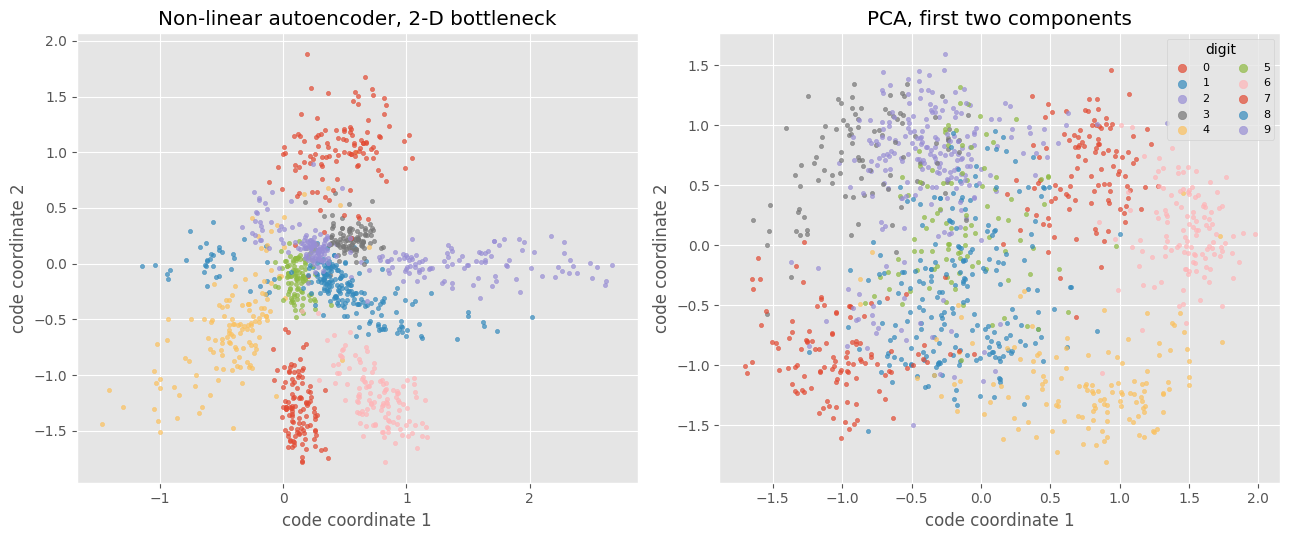

In [15]:
Z_ae = nonlinear_models[2].encode(X_test)
Z_pca = (X_test - pca_mean) @ components[:, :2]

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

for a, Z, title in [(ax[0], Z_ae, 'Non-linear autoencoder, 2-D bottleneck'),
                    (ax[1], Z_pca, 'PCA, first two components')]:
    for d in range(10):
        m = y_test == d
        a.scatter(Z[m, 0], Z[m, 1], s=9, alpha=0.7, label=str(d))
    a.set_xlabel('code coordinate 1')
    a.set_ylabel('code coordinate 2')
    a.set_title(title)

ax[1].legend(title='digit', markerscale=2, ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

To put a number on what the picture shows rather than reading it by eye, the cell below uses the
labels for the first time. For every test digit it finds the nearest other test digit in code space
and asks whether the two carry the same label. This is a 1-nearest-neighbour agreement rate, and it
measures how much class structure a 2-number code retains; the same quantity is computed on the raw
64 pixels as a ceiling and on the PCA plane for comparison. Chance is about 10%.

In [16]:
def neighbour_agreement(Z, y):
    # squared distances between every pair, expanded so no 3-D array is built
    sq = (Z ** 2).sum(axis=1)
    d = sq[:, None] + sq[None, :] - 2 * (Z @ Z.T)
    np.fill_diagonal(d, np.inf)
    return (y[d.argmin(axis=1)] == y).mean()


print(f'{"representation":34s} {"dims":>5s} {"1-NN label agreement":>21s}')
print(f'{"raw pixels":34s} {64:5d} {neighbour_agreement(X_test, y_test):21.4f}')
print(f'{"PCA, 2 components":34s} {2:5d} {neighbour_agreement(Z_pca, y_test):21.4f}')
print(f'{"autoencoder code, k = 2":34s} {2:5d} {neighbour_agreement(Z_ae, y_test):21.4f}')
for k in [kk for kk in ks if kk >= 8]:
    print(f'{"autoencoder code, k = " + str(k):34s} {k:5d}'
          f' {neighbour_agreement(nonlinear_models[k].encode(X_test), y_test):21.4f}')

representation                      dims  1-NN label agreement
raw pixels                            64                0.9706
PCA, 2 components                      2                0.5418
autoencoder code, k = 2                2                0.8265
autoencoder code, k = 8                8                0.9484
autoencoder code, k = 16              16                0.9573
autoencoder code, k = 32              32                0.9644


## What the decoder learned

For the linear autoencoder the decoder is a matrix, and

$$\hat{\mathbf{x}} = \sum_{j=1}^{k} z_j \, \mathbf{w}_j + \mathbf{b}_d$$

so every reconstruction is a weighted sum of the $k$ rows of $W_d$ plus a fixed offset. Each row is
64 numbers, one per pixel, so it can be folded back into an 8x8 image and looked at: these are the
parts the decoder adds together, and the code says how much of each to use.

The cell draws the eight rows of the $k = 8$ linear decoder on the top and the first eight principal
components on the bottom, both as images with a diverging scale so that positive and negative weight
are distinguishable. They span the same subspace but not with the same axes, so the two rows are not
expected to match picture by picture - the decoder's are an arbitrary mixture of the components'.

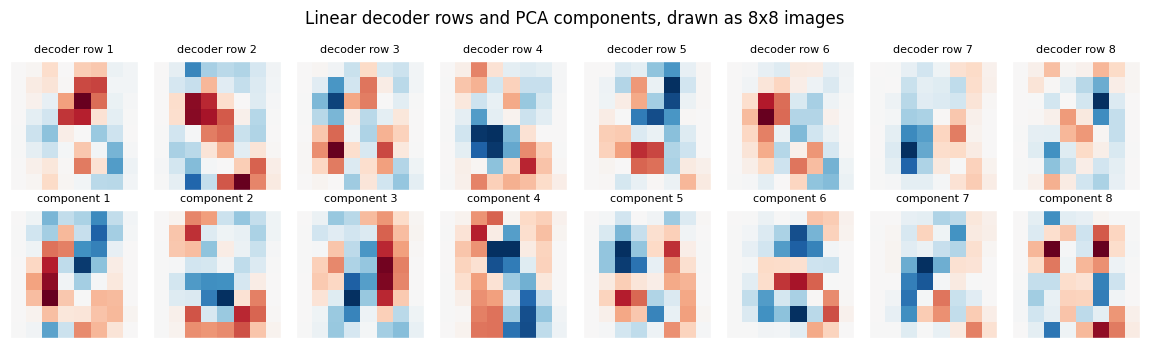

In [17]:
k = 8
Wd = linear_models[k].weights[1]

fig, ax = plt.subplots(2, k, figsize=(1.45 * k, 3.6))

for j in range(k):
    for row, image, name in [(0, Wd[j], 'decoder row'), (1, components[:, j], 'component')]:
        limit = np.abs(image).max()
        a = ax[row, j]
        a.imshow(image.reshape(8, 8), cmap='RdBu_r', vmin=-limit, vmax=limit)
        a.set_xticks([])
        a.set_yticks([])
        a.grid(False)
        a.set_title(f'{name} {j + 1}', fontsize=8)

plt.suptitle('Linear decoder rows and PCA components, drawn as 8x8 images')
plt.tight_layout()
plt.show()

## The denoising autoencoder

A bottleneck is not the only way to stop a network learning the identity. Corrupt the input and ask
for the clean image back:

$$J = \frac{1}{N}\sum_i \lVert \mathbf{x}_i - g(f(\tilde{\mathbf{x}}_i)) \rVert^2, \qquad
\tilde{\mathbf{x}} = \mathbf{x} + \boldsymbol\epsilon, \quad
\boldsymbol\epsilon \sim \mathcal{N}(0, \sigma^2 I)$$

Copying the input is now the wrong answer, because the input is not what is being asked for. To
lower this loss the network has to work out which parts of what it sees are digit and which are
noise, and it can only do that by knowing what digits look like. The noise is redrawn every time an
image is used, so the network sees a different corruption of the same digit at each epoch and cannot
memorise the pairing.

Geometrically, corrupting pushes points off the surface the digits live on and the target pulls them
back onto it, so the map being learned is a projection towards that surface. That is a stronger
requirement than compression: it says something about the whole neighbourhood of the data, not only
about the data.

The cell trains a denoising autoencoder at two noise levels, plus a plain one for reference, all at
the same bottleneck size, and evaluates every one of them on corrupted test digits.

In [18]:
noise_levels = [0.3, 0.6]
denoisers = {}
start = time.time()

for sigma in noise_levels:
    ae = Autoencoder([64, 128, 16, 128, 64], learning_rate=0.004, seed=0)
    ae.fit(X_train, X_test, epochs=150, batch_size=128, noise=sigma, seed=0)
    denoisers[sigma] = ae
    print(f'trained sigma = {sigma}   {time.time() - start:.1f} s elapsed')

plain = nonlinear_models[16]

r = np.random.default_rng(7)
corrupted = {s: np.clip(X_test + r.normal(0, s, X_test.shape), 0, 1) for s in noise_levels}

print()
print(f'{"model":28s} {"test sigma":>11s} {"J vs clean":>11s} {"RMSE":>8s}')
for sigma in noise_levels:
    Xc = corrupted[sigma]
    print(f'{"corrupted input itself":28s} {sigma:11.1f}'
          f' {recon_loss(X_test, Xc):11.5f} {per_pixel_rmse(X_test, Xc):8.4f}')
    for name, model in [('plain autoencoder', plain), (f'denoiser trained at {sigma}', denoisers[sigma])]:
        out = model.forward(Xc)
        print(f'{name:28s} {sigma:11.1f} {recon_loss(X_test, out):11.5f} {per_pixel_rmse(X_test, out):8.4f}')
    print()

trained sigma = 0.3   7.8 s elapsed


trained sigma = 0.6   15.4 s elapsed

model                         test sigma  J vs clean     RMSE
corrupted input itself               0.3     3.30977   0.2274
plain autoencoder                    0.3     3.44679   0.2321
denoiser trained at 0.3              0.3     1.23551   0.1389

corrupted input itself               0.6     9.54965   0.3863
plain autoencoder                    0.6     8.58652   0.3663
denoiser trained at 0.6              0.6     2.51841   0.1984



The figure shows what those numbers look like. For each noise level there is a row of clean digits, a
row of the corrupted versions the model actually receives, and a row of what comes back out.

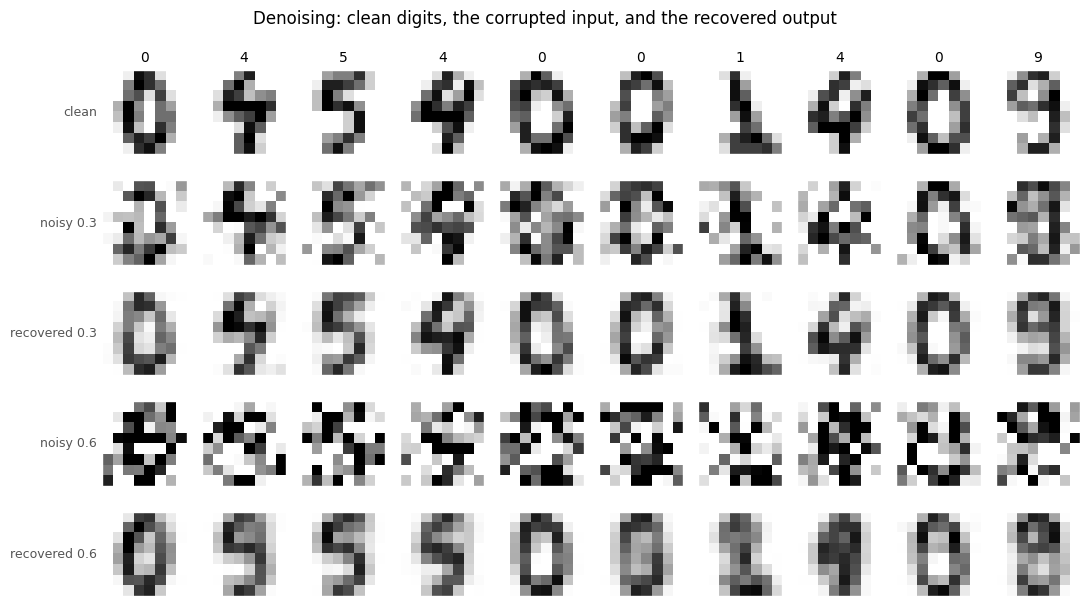

In [19]:
picks = np.arange(10)

fig, ax = plt.subplots(1 + 2 * len(noise_levels), 10, figsize=(11, 1.25 * (1 + 2 * len(noise_levels))))

rows = [('clean', X_test[picks])]
for sigma in noise_levels:
    rows.append((f'noisy {sigma}', corrupted[sigma][picks]))
    rows.append((f'recovered {sigma}', denoisers[sigma].forward(corrupted[sigma])[picks]))

for row, (label, images) in enumerate(rows):
    for col in range(10):
        a = ax[row, col]
        a.imshow(images[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        a.set_xticks([])
        a.set_yticks([])
        a.grid(False)
        if col == 0:
            a.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
        if row == 0:
            a.set_title(str(y_test[picks[col]]), fontsize=10)

plt.suptitle('Denoising: clean digits, the corrupted input, and the recovered output')
plt.tight_layout()
plt.show()

## Training curves

Test reconstruction error per epoch for the three variants at the same bottleneck size, with the PCA
error drawn as a horizontal line. The linear autoencoder approaches that line from above and stops
there. The denoising curve is measured against clean targets from clean inputs, so it is not
comparable to the others as a number - it is included to show that it converges, not that it wins.

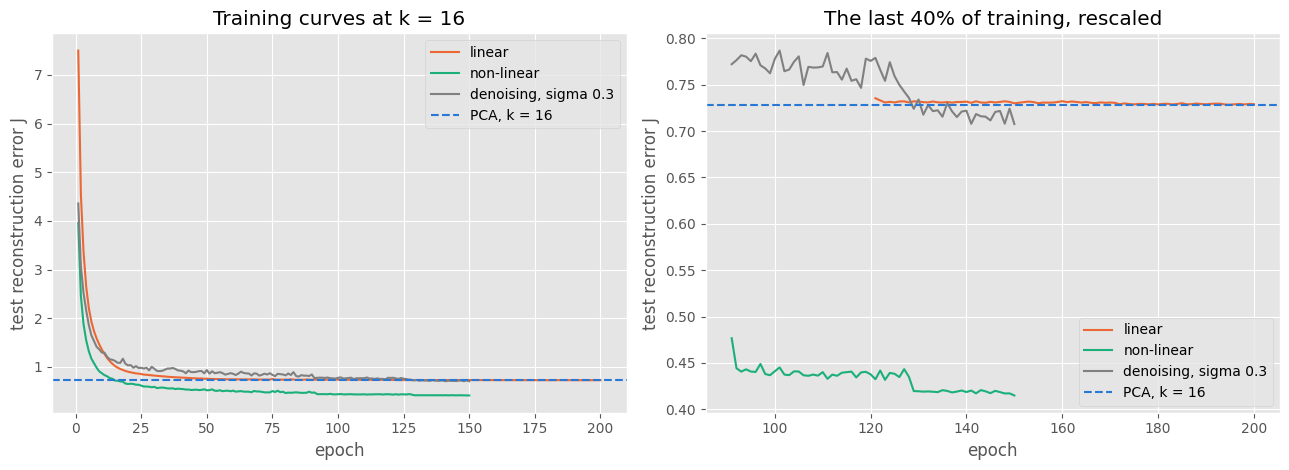

In [20]:
kk = 16

curves = [('linear', linear_models[kk], orange),
          ('non-linear', nonlinear_models[kk], green),
          (f'denoising, sigma {noise_levels[0]}', denoisers[noise_levels[0]], 'grey')]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

for a, first in zip(ax, [0, 0.6]):
    for label, model, colour in curves:
        loss = np.array(model.history['test_loss'])
        e = np.arange(1, len(loss) + 1)
        keep = e > first * len(loss)
        a.plot(e[keep], loss[keep], color=colour, label=label)
    a.axhline(recon_loss(X_test, pca_reconstruct(X_test, kk)), color=blue, linestyle='--',
              label=f'PCA, k = {kk}')
    a.set_xlabel('epoch')
    a.set_ylabel('test reconstruction error J')
    a.legend()

ax[0].set_title(f'Training curves at k = {kk}')
ax[1].set_title('The last 40% of training, rescaled')

plt.tight_layout()
plt.show()

## Using the decoder on its own

Once trained, the decoder is a function from $k$ numbers to an image and can be run without an
encoder in front of it. Two things are drawn from it.

**Interpolation.** Take two test digits, encode both, and walk along the straight line between their
codes,

$$\mathbf{z}(t) = (1 - t)\,\mathbf{z}_a + t\,\mathbf{z}_b, \qquad t \in [0, 1]$$

decoding at each step. Interpolating the pixels instead would fade one image out while the other
fades in, showing both at once in the middle. Interpolating the code shows what the model believes
lies between the two digits, which is a statement about the surface it has learned.

**Made-up codes.** Feeding the decoder a code no image produced - the mean code plus a multiple of
one code coordinate - shows what that single number controls.

Both rows use the $k$ = 16 non-linear model. The pixel interpolation is drawn underneath for
comparison.

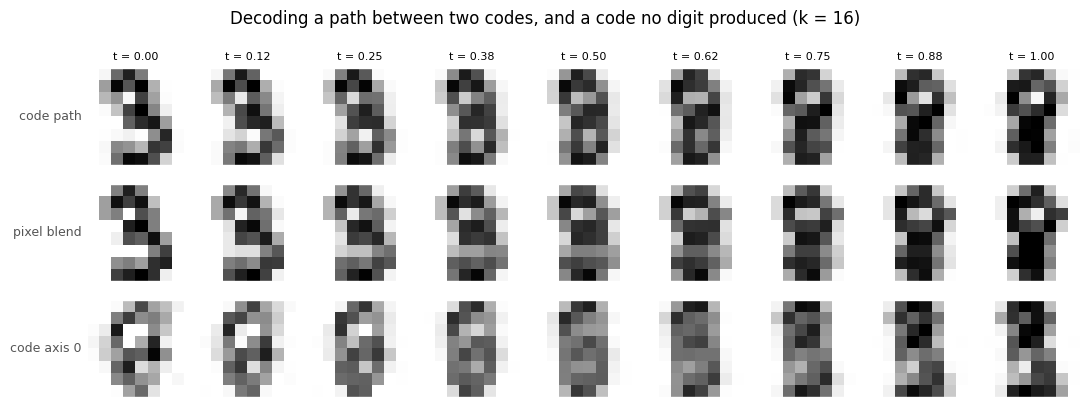

In [21]:
model = nonlinear_models[16]
a_idx = int(np.where(y_test == 3)[0][0])
b_idx = int(np.where(y_test == 8)[0][0])

ts = np.linspace(0, 1, 9)
za, zb = model.encode(X_test[[a_idx]]), model.encode(X_test[[b_idx]])
code_walk = model.decode(np.vstack([(1 - t) * za + t * zb for t in ts]))
pixel_walk = np.vstack([(1 - t) * X_test[a_idx] + t * X_test[b_idx] for t in ts])

Z_train = model.encode(X_train)
mean_code = Z_train.mean(axis=0)
spread = Z_train.std(axis=0)
axis = int(np.argmax(spread))
made_up = model.decode(np.vstack([mean_code + m * spread[axis] * np.eye(16)[axis]
                                  for m in np.linspace(-2.5, 2.5, 9)]))

fig, ax = plt.subplots(3, 9, figsize=(11, 4.2))

rows = [('code path', code_walk), ('pixel blend', pixel_walk), (f'code axis {axis}', made_up)]
for row, (label, images) in enumerate(rows):
    for col in range(9):
        a = ax[row, col]
        a.imshow(images[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        a.set_xticks([])
        a.set_yticks([])
        a.grid(False)
        if col == 0:
            a.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
for col, t in enumerate(ts):
    ax[0, col].set_title(f't = {t:.2f}', fontsize=8)

plt.suptitle(f'Decoding a path between two codes, and a code no digit produced (k = {16})')
plt.tight_layout()
plt.show()

## Summary

In [22]:
print(f'{"k":>4s} {"PCA J":>9s} {"linear AE":>10s} {"ratio":>7s} {"non-linear":>11s} {"NL vs PCA":>10s}')
for k in ks:
    pj = recon_loss(X_train, pca_reconstruct(X_train, k))
    lj = linear_models[k].history['train_loss'][-1]
    nj = nonlinear_models[k].history['train_loss'][-1]
    print(f'{k:4d} {pj:9.5f} {lj:10.5f} {lj / pj:7.4f} {nj:11.5f} {100 * (nj - pj) / pj:9.1f}%')

print()
print(f'total notebook runtime: {time.time() - notebook_start:.1f} s')

   k     PCA J  linear AE   ratio  non-linear  NL vs PCA
   2   3.38324    3.38384  1.0002     1.77825     -47.4%
   4   2.43566    2.43583  1.0001     1.15462     -52.6%
   8   1.54416    1.54499  1.0005     0.64553     -58.2%
  16   0.71291    0.71344  1.0008     0.38073     -46.6%
  32   0.16385    0.16476  1.0056     0.12074     -26.3%

total notebook runtime: 76.7 s


- An autoencoder is trained on $J = \frac{1}{N}\sum_i \lVert \mathbf{x}_i - \hat{\mathbf{x}}_i\rVert^2$
  with the input as its own target. No label enters the training of any model in this notebook; the
  labels colour one scatter plot and score the codes in one table.
- The backward pass is the ordinary $\boldsymbol\delta^{(l)} = (W^{(l+1)}\boldsymbol\delta^{(l+1)})
  \odot g'(\mathbf{z}^{(l)})$ recurrence started from $\boldsymbol\delta^{(L)} = \frac{2}{N}
  (\hat{\mathbf{x}} - \mathbf{x})$. The only thing that makes the network an autoencoder rather than
  a classifier is the target and the width of the middle layer.
- With no activations the network reaches PCA's reconstruction error at every bottleneck size, and
  the principal angles between its decoder's span and the leading principal components are a
  fraction of a degree. It does **not** recover the components themselves: $W_dW_e =
  (W_dA^{-1})(AW_e)$ for any invertible $A$, so the code's axes are fixed only up to rotation,
  scaling and shear. The decoder's rows are not orthogonal and match no component, while the
  reconstructions agree to a few thousandths.
- ReLU layers around the bottleneck remove the restriction to a flat subspace and lower the error at
  the small bottlenecks, where a plane fits the data worst. The margin narrows as $k$ grows, because
  a linear subspace of higher dimension already covers most of the variation, and at the largest $k$
  the remaining error is small enough that how well the optimiser converges matters more than what
  the model can represent.
- A per-pixel RMSE is the interpretable version of the loss. Reconstructions become visibly sharper
  with $k$, and the sharpening is fastest over the first few components.
- Corrupting the input while keeping the target clean makes the identity map the wrong answer, so the
  network has to separate digit from noise. The denoiser trained at a given noise level recovers
  digits that the corrupted input itself represents far worse, and it beats a plain autoencoder given
  the same corrupted input.
- The two-dimensional code separates some digits and merges others. That is the expected outcome:
  two numbers cannot hold ten classes, and no label was available to tell the encoder which
  differences were the ones worth keeping.
- The decoder is a generative map on its own. Decoding a straight path between two codes produces a
  sequence of digit-like images rather than the double exposure that blending the pixels gives, which
  is the clearest evidence that the code space has been organised rather than merely compressed.